In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.parallel import DataParallel
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
from torchinfo import summary

In [2]:
import numpy as np

# def generate_tvar_sample(
#     p, T=600, W=40, P0=0.5, sigma_noise=0.2, burnin=300, 
#     weight_scale=0.25, seed=None, standardize=False
# ):
#     """
#     Generate one TVAR(p) sample where coefficients adapt to constrain power.
    
#     Args:
#         standardize (bool): Set to False to see the effect of P0 constraint. 
#                             If True, the final output is forced to variance=1.
#     """
#     rng = np.random.default_rng(seed)
    
#     # 1. Initialize base coefficients
#     # We start with random coefficients
#     current_coeffs = rng.normal(0.0, weight_scale, size=p)
    
#     total = T + burnin
#     x = np.zeros(total, dtype=float)
    
#     # Storage for time-varying coefficients
#     # Shape: (Total, p) to track changes at every step
#     coeffs_history = np.zeros((total, p))
    
#     # Initialize process with noise
#     eps = rng.normal(0.0, sigma_noise, size=total)
#     x[:p] = rng.normal(0.0, sigma_noise, size=p)
    
#     # Fill history for the initial lags
#     coeffs_history[:p] = current_coeffs

#     # 2. Simulation Loop
#     for t in range(p, total):
#         # A. Calculate Power in the sliding window W
#         # We look at x[t-W : t]
#         window_start = max(0, t - W)
#         # Handle edge case where window is smaller than 1
#         if t - window_start > 0:
#             current_power = np.mean(x[window_start:t]**2)
#         else:
#             current_power = 0.0

#         # B. Recursive Reduction
#         # If power exceeds P0, shrink the coefficients
#         if current_power > P0:
#             decay_factor = 0.98  # Reduce magnitude by 2% per step until power drops
#             current_coeffs = current_coeffs * decay_factor
            
#         # Store the coefficients used for this step
#         coeffs_history[t] = current_coeffs

#         # C. Generate the next sample
#         lags = x[t-p:t][::-1]
#         x[t] = float(np.dot(current_coeffs, lags) + eps[t])
    
#     # 3. Final Cleanup
#     x = x[burnin:]
#     coeffs = coeffs_history[burnin:]
    
#     # Note: If you standardize, you will overwrite the P0 power level to 1.0.
#     # Usually, if you want P0 to matter, you should set standardize=False.
#     if standardize:
#         x = (x - x.mean()) / (x.std() + 1e-12)
    
#     return x, coeffs


def generate_fixed_ar_torus(n_samples=600, ar_order=3, noise_std=0.05, fs=100):
    """
    Generate fixed AR process with coefficients designed to produce torus topology.
    
    Key insight: AR process with complex conjugate poles near unit circle
    creates oscillatory (quasi-periodic) behavior.
    
    Args:
        n_samples: Length of signal
        ar_order: AR order (3, 4, 5, or 6 recommended)
        noise_std: Innovation noise level
        fs: Sampling frequency
        
    Returns:
        x: Generated signal (n_samples,)
        coeffs: AR coefficients repeated per timestep (n_samples, ar_order)
    """
    
    if ar_order == 2:
        # AR(2): One complex conjugate pair
        r1 = 0.96
        f1 = 2.0
        theta1 = 2 * np.pi * f1 / fs
        poles = [r1 * np.exp(1j * theta1), r1 * np.exp(-1j * theta1)]
        
    elif ar_order == 3:
        # AR(3): One complex conjugate pair + one real pole
        r1 = 0.95
        f1 = 2.5
        theta1 = 2 * np.pi * f1 / fs
        pole1 = r1 * np.exp(1j * theta1)
        pole2 = r1 * np.exp(-1j * theta1)
        pole3 = 0.3
        poles = [pole1, pole2, pole3]
        
    elif ar_order == 4:
        # AR(4): Two complex conjugate pairs (creates torus!)
        r1, r2 = 0.93, 0.88
        f1, f2 = 2.0, 3.2
        theta1 = 2 * np.pi * f1 / fs
        theta2 = 2 * np.pi * f2 / fs
        poles = [
            r1 * np.exp(1j * theta1), r1 * np.exp(-1j * theta1),
            r2 * np.exp(1j * theta2), r2 * np.exp(-1j * theta2)
        ]
        
    elif ar_order == 5:
        # AR(5): Two complex pairs + one real
        r1, r2 = 0.92, 0.87
        f1, f2 = 1.8, 2.9
        theta1 = 2 * np.pi * f1 / fs
        theta2 = 2 * np.pi * f2 / fs
        poles = [
            r1 * np.exp(1j * theta1), r1 * np.exp(-1j * theta1),
            r2 * np.exp(1j * theta2), r2 * np.exp(-1j * theta2),
            0.4
        ]
        
    elif ar_order == 6:
        # AR(6): Three complex conjugate pairs
        r1, r2, r3 = 0.91, 0.86, 0.80
        f1, f2, f3 = 1.7, 2.7, 4.1
        theta1 = 2 * np.pi * f1 / fs
        theta2 = 2 * np.pi * f2 / fs
        theta3 = 2 * np.pi * f3 / fs
        poles = [
            r1 * np.exp(1j * theta1), r1 * np.exp(-1j * theta1),
            r2 * np.exp(1j * theta2), r2 * np.exp(-1j * theta2),
            r3 * np.exp(1j * theta3), r3 * np.exp(-1j * theta3)
        ]
    else:
        raise ValueError("ar_order must be 2, 3, 4, 5, or 6")
    
    # Convert poles to AR coefficients
    ar_poly = np.poly(poles)
    coeffs = np.real_if_close(-ar_poly[1:], tol=1e6).astype(float)
    
    # Generate AR process
    x = np.zeros(n_samples)
    x[:ar_order] = noise_std * np.random.randn(ar_order)
    
    for t in range(ar_order, n_samples):
        ar_sum = sum(coeffs[i] * x[t - i - 1] for i in range(ar_order))
        x[t] = ar_sum + noise_std * np.random.randn()
    
    # Normalize
    x = x / (np.std(x) + 1e-8)
    
    # Return coeffs as (n_samples, ar_order) for TVAR format compatibility
    coeffs_expanded = np.tile(coeffs, (n_samples, 1))
    
    return x, coeffs_expanded

In [3]:
def generate_dataset(n_samples, p_min=2, p_max=6, T=600):
    X = np.zeros((n_samples, T))
    coeffs_all = np.zeros((n_samples, T, p_max))
    p_true = np.zeros(n_samples, dtype=np.int64)
    
    for i in tqdm(range(n_samples)):
        p = np.random.randint(p_min, p_max + 1)
        x, coeffs = generate_fixed_ar_torus(ar_order=p, n_samples=T)
        X[i] = x
        coeffs_all[i, :, :p] = coeffs
        p_true[i] = p - p_min  # 0-indexed for cross entropy
    
    return X, coeffs_all, p_true

In [4]:
def plot_tvar_sample(x, coeffs, p, W=40, P0=0.5):
    T = len(x)
    
    # Compute sliding window power
    power = np.zeros(T)
    for i in range(T):
        start = max(0, i - W + 1)
        power[i] = np.mean(x[start:i + 1] ** 2)
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    
    # Coefficients
    for k in range(p):
        axes[0].plot(coeffs[:, k], label=f'a{k+1}')
    axes[0].set_ylabel('Coefficients')
    axes[0].legend(loc='upper right')
    
    # Signal
    axes[1].plot(x)
    axes[1].set_ylabel('Amplitude')
    
    # Power
    axes[2].plot(power, color='tab:orange')
    axes[2].axhline(P0, color='k', linestyle='--')
    axes[2].set_ylabel('Power')
    axes[2].set_xlabel('Time')
    
    plt.tight_layout()
    plt.show()

In [5]:
example_sample = generate_fixed_ar_torus(ar_order=3)
example_sample[0].shape, example_sample[1].shape

((600,), (600, 3))

In [6]:
# plot_tvar_sample(example_sample[0], example_sample[1], p=3)

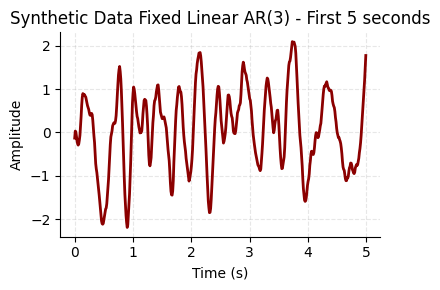

In [7]:
plot_t_snip = np.arange(len(example_sample[0])) / 100  # assuming Fs=100 Hz

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(plot_t_snip[:500], example_sample[0][:500], lw=2.0, color="darkred")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Synthetic Data Fixed Linear AR(3) - First 5 seconds")
ax.grid(True, ls='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
 

In [8]:
# ============== GLOBAL PLOT STYLE ==============
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "lines.linewidth": 1.8,
    "lines.markersize": 5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

color_main = "black"
color_alt = "darkred"

def prettify(ax, title=None, xlabel=None, ylabel=None, add_legend=False):
    """Unified styling for axes"""
    if title: ax.set_title(title, pad=10)
    if xlabel: ax.set_xlabel(xlabel, labelpad=5)
    if ylabel: ax.set_ylabel(ylabel, labelpad=5)
    ax.grid(alpha=0.0, linestyle="--", linewidth=0.7)
    if add_legend: 
        ax.legend(frameon=False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(1.0)

print("Plot style configured.")

Plot style configured.


In [9]:
class TVARNet(nn.Module):
    def __init__(self, seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128):
        """
        Args:
            seq_len: Length of input sequence
            n_classes: Number of AR order classes (5 for p∈{2,3,4,5,6})
            max_ar_order: Maximum AR order for coefficient output (6 for AR(6))
            hidden_dim: Hidden layer dimension
        """
        super().__init__()
        self.seq_len = seq_len
        self.n_classes = n_classes
        self.max_ar_order = max_ar_order
        
        # P-Block: predicts order class (n_classes outputs)
        self.p_block = nn.Sequential(
            nn.Linear(seq_len, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_classes)
        )
        
        # D-Block: (N, seq_len + n_classes) -> (N, seq_len * max_ar_order)
        self.d_block = nn.Sequential(
            nn.Linear(seq_len + n_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, seq_len * max_ar_order)
        )
    
    def forward(self, x, temperature=1.0):
        # x: (N, seq_len)
        N = x.shape[0]
        
        # P-Block: predict class (0 to n_classes-1)
        p_logits = self.p_block(x)  # (N, n_classes)
        p_soft = F.gumbel_softmax(p_logits, tau=temperature, hard=True)  # (N, n_classes)
        p_hard = torch.argmax(p_soft, dim=-1)  # (N,) values in [0, n_classes-1]
        
        # Convert class to AR order: class 0 -> p=2, class 4 -> p=6
        # So we need (p_hard + 2) coefficients active
        # Mask: indices 0...(p_hard+1) should be active
        indices = torch.arange(self.max_ar_order, device=x.device).unsqueeze(0)  # (1, max_ar_order)
        mask = (indices <= p_hard.unsqueeze(1) + 1).float()  # (N, max_ar_order)
        
        # D-Block: concat x and p_soft
        d_input = torch.cat([x, p_soft], dim=1)  # (N, seq_len + n_classes)
        coeffs_raw = self.d_block(d_input)  # (N, seq_len * max_ar_order)
        coeffs_raw = coeffs_raw.view(N, self.seq_len, self.max_ar_order)  # (N, seq_len, max_ar_order)
        
        # Apply mask
        coeffs = coeffs_raw * mask.unsqueeze(1)  # (N, seq_len, max_ar_order)
        
        # Vectorized AR: build lag matrix and do batch matmul
        # x_lagged[:, t, k] = x[:, t - k - 1]
        x_lagged = torch.zeros(N, self.seq_len, self.max_ar_order, device=x.device)
        for k in range(self.max_ar_order):
            x_lagged[:, k+1:, k] = x[:, :self.seq_len - k - 1]
        
        # x_hat[n, t] = sum_k coeffs[n, t, k] * x_lagged[n, t, k]
        x_hat = (coeffs * x_lagged).sum(dim=-1)  # (N, seq_len)
        
        return coeffs, p_logits, p_hard, x_hat


In [10]:
def loss_p(p_logits, p_true):
    return F.cross_entropy(p_logits, p_true)

def loss_ar(x, x_hat, p_max):
    return F.mse_loss(x_hat[:, p_max:], x[:, p_max:])

def loss_energy(x_hat, P0=0.5, W=40):
    # Use unfold for sliding window
    N, T = x_hat.shape
    # Pad at start so we get T windows
    x_padded = F.pad(x_hat, (W - 1, 0), mode='constant', value=0)
    windows = x_padded.unfold(1, W, 1)  # (N, T, W)
    powers = (windows ** 2).mean(dim=-1)  # (N, T)
    return ((powers - P0) ** 2).mean()

def loss_smooth(coeffs):
    diff = coeffs[:, 1:, :] - coeffs[:, :-1, :]
    return torch.mean(torch.sum(diff ** 2, dim=2))

def loss_order(p_logits):
    """Regularizer to prefer lower AR orders.
    Computes expected order index from softmax probabilities and penalizes higher values.
    """
    # p_logits: (N, n_classes) where class 0 -> p=2, class 4 -> p=6
    n_classes = p_logits.shape[1]
    probs = F.softmax(p_logits, dim=-1)  # (N, n_classes)
    indices = torch.arange(n_classes, device=p_logits.device, dtype=p_logits.dtype)  # [0, 1, 2, 3, 4]
    expected_order = (probs * indices).sum(dim=-1)  # (N,) expected class index
    return expected_order.mean()  # Minimize expected order

In [11]:
# Generate data
np.random.seed(42)
X_train, coef_train, p_train = generate_dataset(10000, p_min=2, p_max=6)
X_val, coef_val, p_val = generate_dataset(1000, p_min=2, p_max=6)

# np.savez_compressed('model/tvar_dataset.npz',
#                     X_train=X_train, coef_train=coef_train, p_train=p_train,
#                     X_val=X_val, coef_val=coef_val, p_val=p_val)

# d = np.load('model/tvar_dataset.npz')
# X_train, coef_train, \
#     p_train, X_val, coef_val, p_val = [d[k][:] for k in ['X_train', 'coef_train', 
#                                                       'p_train', 'X_val', 'coef_val', 'p_val']]
# d.close()


100%|██████████| 1000/1000 [00:00<00:00, 1370.76it/s]


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.cuda.init()
print(f"Using device: {device}")

# To tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
p_train = torch.tensor(p_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.float32)
p_val = torch.tensor(p_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, p_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, p_val), batch_size=32)

# Model: n_classes=5 for p∈{2,3,4,5,6}, max_ar_order=6 for coefficient dimensions
model = TVARNet(seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128)
# model = DataParallel(model)
model = model.to(device)

Using device: cuda


In [13]:
summary(model, input_size=(32, 600), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
TVARNet                                  [32, 600, 6]              --
├─Sequential: 1-1                        [32, 5]                   --
│    └─Linear: 2-1                       [32, 128]                 76,928
│    └─ReLU: 2-2                         [32, 128]                 --
│    └─Linear: 2-3                       [32, 128]                 16,512
│    └─ReLU: 2-4                         [32, 128]                 --
│    └─Linear: 2-5                       [32, 5]                   645
├─Sequential: 1-2                        [32, 3600]                --
│    └─Linear: 2-6                       [32, 128]                 77,568
│    └─ReLU: 2-7                         [32, 128]                 --
│    └─Linear: 2-8                       [32, 128]                 16,512
│    └─ReLU: 2-9                         [32, 128]                 --
│    └─Linear: 2-10                      [32, 3600]                4

In [14]:
def train(
    model,
    train_loader,
    val_loader,
    n_epochs=100,
    lr=1e-3,
    lambda_p=10.0,
    lambda_ar=1.0,
    lambda_energy=0.1,
    lambda_smooth=0.05,
    lambda_order=0.0,
    P0=0.5,
    W=40,
    p_max=6,
    device='cuda'
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    history = {
        'train_loss': [], 'train_p': [], 'train_ar': [], 'train_energy': [], 'train_smooth': [], 'train_order': [], 'train_p_acc': [],
        'val_loss': [], 'val_p': [], 'val_ar': [], 'val_energy': [], 'val_smooth': [], 'val_order': [], 'val_p_acc': []
    }
    
    pbar = tqdm(total=n_epochs, desc='Training')
    for epoch in range(n_epochs):
        # Train
        model.train()
        train_losses = {'total': [], 'p': [], 'ar': [], 'energy': [], 'smooth': [], 'order': []}
        train_correct = 0
        train_total = 0
        
        for x_batch, p_batch in train_loader:
            x_batch = x_batch.to(device)
            p_batch = p_batch.to(device)
            
            optimizer.zero_grad()
            
            coeffs, p_logits, p_hard, x_hat = model(x_batch)
            
            l_p = loss_p(p_logits, p_batch)
            l_ar = loss_ar(x_batch, x_hat, p_max)
            l_energy = loss_energy(x_hat, P0, W)
            l_smooth = loss_smooth(coeffs)
            l_order = loss_order(p_logits)
            
            total_loss = lambda_p * l_p + lambda_ar * l_ar + lambda_energy * l_energy + lambda_smooth * l_smooth + lambda_order * l_order
            
            total_loss.backward()
            optimizer.step()
            
            train_losses['total'].append(total_loss.item())
            train_losses['p'].append(l_p.item())
            train_losses['ar'].append(l_ar.item())
            train_losses['energy'].append(l_energy.item())
            train_losses['smooth'].append(l_smooth.item())
            train_losses['order'].append(l_order.item())
            
            train_correct += (p_hard == p_batch).sum().item()
            train_total += p_batch.shape[0]
        
        # Validate
        model.eval()
        val_losses = {'total': [], 'p': [], 'ar': [], 'energy': [], 'smooth': [], 'order': []}
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for x_batch, p_batch in val_loader:
                x_batch = x_batch.to(device)
                p_batch = p_batch.to(device)
                
                coeffs, p_logits, p_hard, x_hat = model(x_batch)
                
                l_p = loss_p(p_logits, p_batch)
                l_ar = loss_ar(x_batch, x_hat, p_max)
                l_energy = loss_energy(x_hat, P0, W)
                l_smooth = loss_smooth(coeffs)
                l_order = loss_order(p_logits)
                
                total_loss = lambda_p * l_p + lambda_ar * l_ar + lambda_energy * l_energy + lambda_smooth * l_smooth + lambda_order * l_order
                
                val_losses['total'].append(total_loss.item())
                val_losses['p'].append(l_p.item())
                val_losses['ar'].append(l_ar.item())
                val_losses['energy'].append(l_energy.item())
                val_losses['smooth'].append(l_smooth.item())
                val_losses['order'].append(l_order.item())
                
                val_correct += (p_hard == p_batch).sum().item()
                val_total += p_batch.shape[0]
        
        history['train_loss'].append(np.mean(train_losses['total']))
        history['train_p'].append(np.mean(train_losses['p']))
        history['train_ar'].append(np.mean(train_losses['ar']))
        history['train_energy'].append(np.mean(train_losses['energy']))
        history['train_smooth'].append(np.mean(train_losses['smooth']))
        history['train_order'].append(np.mean(train_losses['order']))
        history['train_p_acc'].append(train_correct / train_total)
        
        history['val_loss'].append(np.mean(val_losses['total']))
        history['val_p'].append(np.mean(val_losses['p']))
        history['val_ar'].append(np.mean(val_losses['ar']))
        history['val_energy'].append(np.mean(val_losses['energy']))
        history['val_smooth'].append(np.mean(val_losses['smooth']))
        history['val_order'].append(np.mean(val_losses['order']))
        history['val_p_acc'].append(val_correct / val_total)
        
        scheduler.step(history['val_loss'][-1])
        
        
        pbar.update(1)
        pbar.set_postfix(
            train=f"{history['train_loss'][-1]:.4f}",
            val=f"{history['val_loss'][-1]:.4f}",
            p_acc=f"{history['val_p_acc'][-1]:.3f}"
        )
    
    pbar.close()
    return history

In [15]:
# hyperparameters
n_epochs = 100
lr = 1e-3
lambda_p = 20 # Regularizer weight for p loss
lambda_ar = 5.0 # Regularizer weight for AR loss
lambda_energy = 0.1 # Regularizer weight for energy loss
lambda_smooth = 10 # Regularizer weight for smoothness loss
lambda_order = 1  # Regularizer to prefer lower AR orders (higher = stronger preference for low p)
max_ar_order = 6  # max AR order for skipping initial samples in loss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Train
history = train(
    model, train_loader, val_loader,
    n_epochs=n_epochs, lr=lr,
    lambda_p=lambda_p, lambda_ar=lambda_ar, lambda_energy=lambda_energy, 
    lambda_smooth=lambda_smooth, lambda_order=lambda_order,
    p_max=max_ar_order, device=device
)

Training: 100%|██████████| 100/100 [00:56<00:00,  1.76it/s, p_acc=0.657, train=2.0822, val=66.9903]


In [16]:
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'history': history
# }, 'model/tvar_model.pt')

# Load
# checkpoint = torch.load('model/tvar_model.pt', weights_only=False)
# model.load_state_dict(checkpoint['model_state_dict'])
# history = checkpoint['history']

In [17]:
def plot_confusion_matrix(model, val_loader, device, p_min=2, p_max=6, ax=None):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    
    model.eval()
    all_p_pred = []
    all_p_true = []
    
    with torch.no_grad():
        for x_batch, p_batch in val_loader:
            x_batch = x_batch.to(device)
            _, _, p_hard, _ = model(x_batch)
            all_p_pred.extend(p_hard.cpu().numpy())
            all_p_true.extend(p_batch.numpy())
    
    n_classes = p_max - p_min + 1  # 5 classes for p=2,3,4,5,6
    cm = confusion_matrix(all_p_true, all_p_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[f'p={i+p_min}' for i in range(n_classes)])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    if ax:
        ax.set_title('P Confusion Matrix')
    return cm

def plot_history(history, model=None, val_loader=None, device=None, p_min=2, p_max=6):
    fig, axes = plt.subplots(2, 6, figsize=(20, 8))
    
    metrics = ['loss', 'p', 'ar', 'energy', 'smooth', 'p_acc']
    titles = ['Total Loss', 'P Loss (CE)', 'AR Loss', 'Energy Loss', 'Smooth Loss', 'P Accuracy']
    
    # Train metrics (row 0)     
    for i, (metric, title) in enumerate(zip(metrics, titles)):
        axes[0, i].plot(history[f'train_{metric}'])
        axes[0, i].set_title(f'Train {title}')
        axes[0, i].set_xlabel('Epoch')
    
    # Val metrics (row 1, first 5)
    for i, (metric, title) in enumerate(zip(metrics[:5], titles[:5])):
        axes[1, i].plot(history[f'val_{metric}'])
        axes[1, i].set_title(f'Val {title}')
        axes[1, i].set_xlabel('Epoch')
    
    # Confusion matrix (row 1, last col)
    if model is not None and val_loader is not None and device is not None:
        plot_confusion_matrix(model, val_loader, device, p_min=p_min, p_max=p_max, ax=axes[1, 5])
    else:
        axes[1, 5].plot(history['val_p_acc'])
        axes[1, 5].set_title('Val P Accuracy')
        axes[1, 5].set_xlabel('Epoch')
    
    plt.tight_layout()
    plt.show()

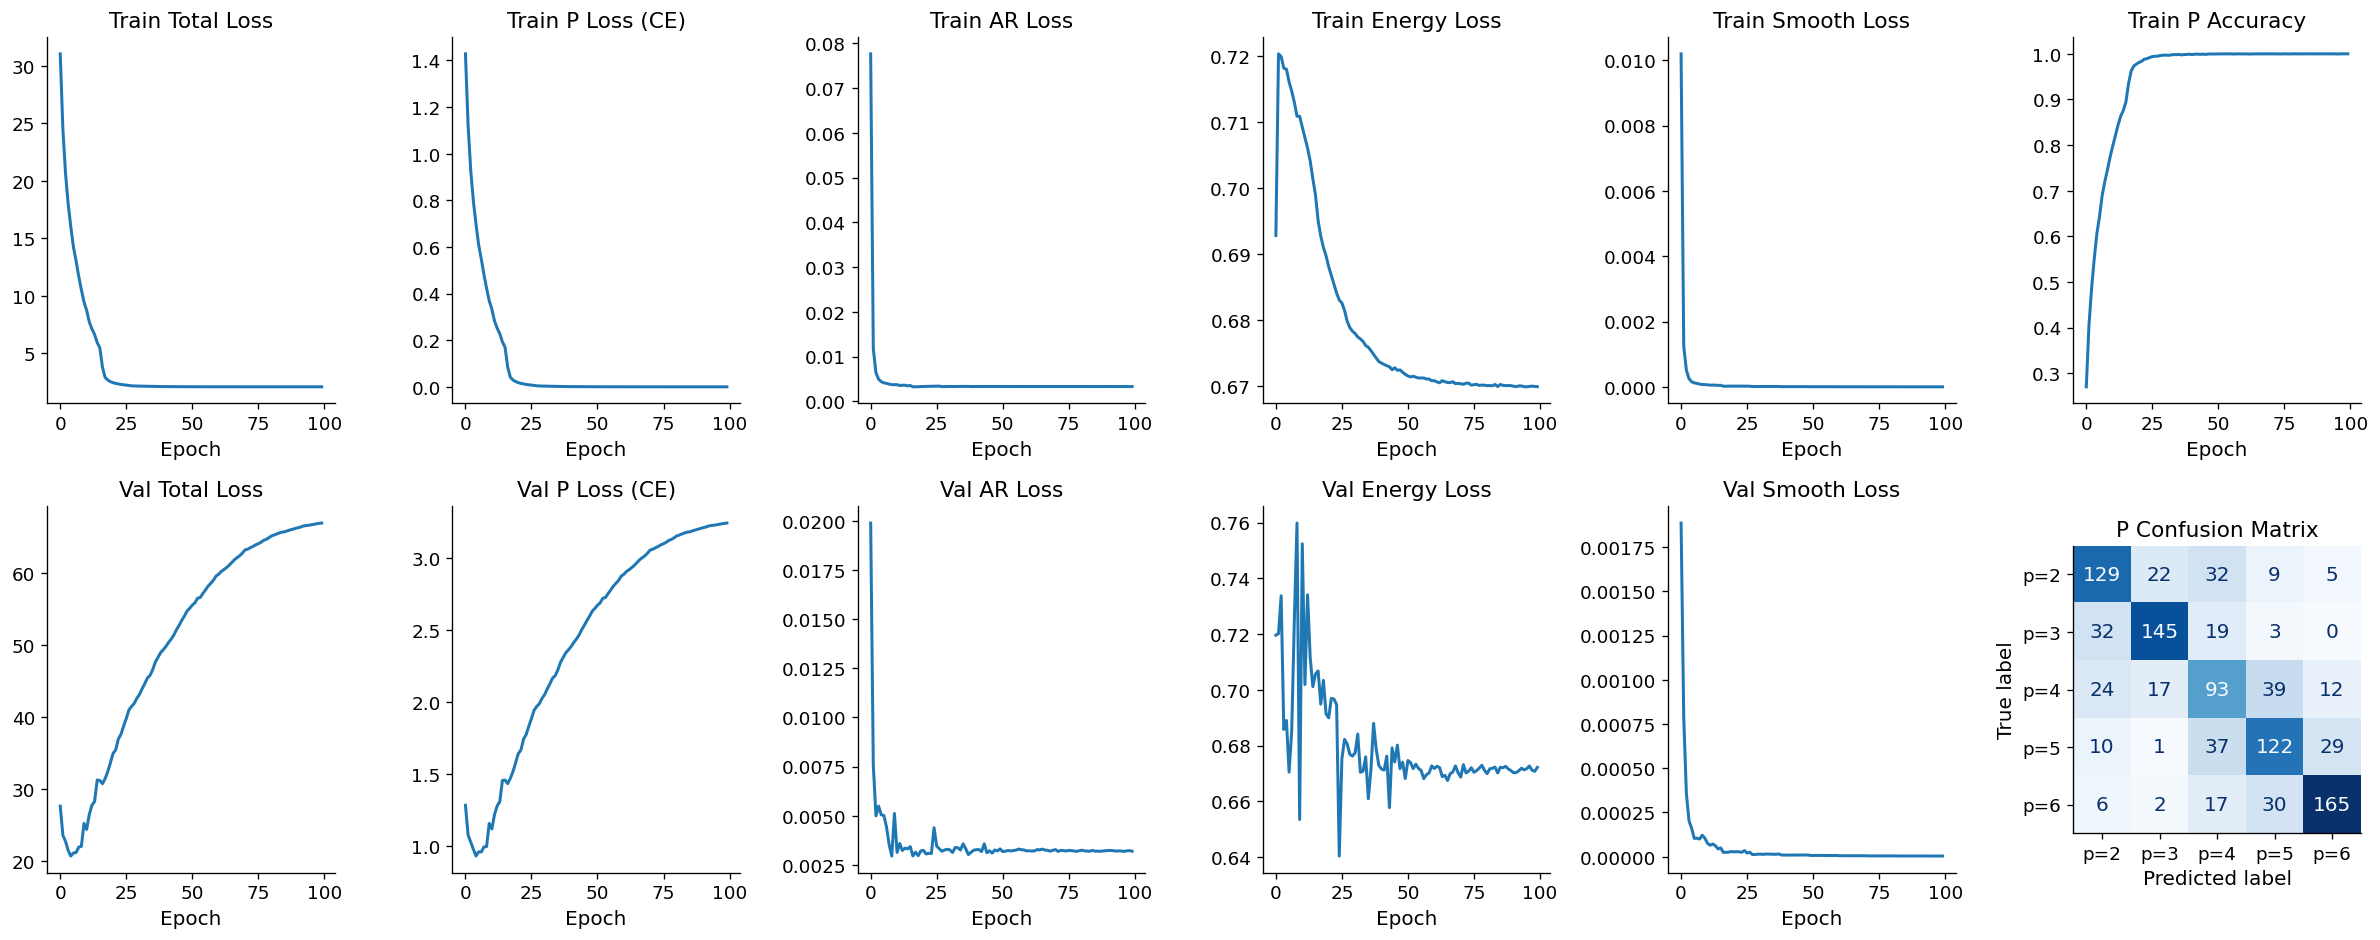

In [18]:
plot_history(history, model=model, val_loader=val_loader, device=device)

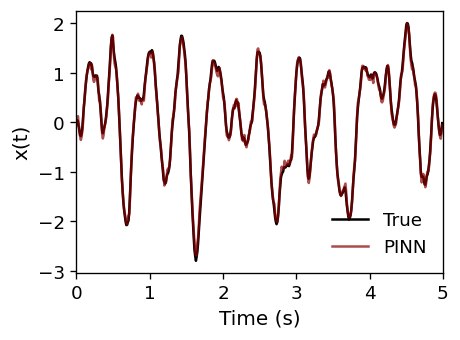

In [19]:
# Pick a sample (e.g. p=3, class index 1)
p3_mask = (p_val == 1).numpy() if torch.is_tensor(p_val) else (p_val == 1)
sample_idx = np.where(p3_mask)[0][0]

# Get true signal
x_true = X_val[sample_idx].cpu().numpy()

# Get PINN reconstruction
model.eval()
with torch.no_grad():
    x_input = X_val[sample_idx:sample_idx+1].to(device)
    _, _, _, x_hat = model(x_input)
    x_hat_np = x_hat.cpu().numpy()[0]

# Plot
T = len(x_true)
t = np.arange(T) / 100  # assuming Fs=100

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(t[:500], x_true[:500], lw=1.5, color="black", label="True")
ax.plot(t[:500], x_hat_np[:500], lw=1.5, color="darkred", alpha=0.7, label="PINN")
ax.set_xlabel("Time (s)")
ax.set_ylabel("x(t)")
ax.legend(frameon=False)

for spine in ax.spines.values():
    spine.set_visible(True)

sec_ticks = np.arange(0, 6, 1)
ax.set_xticks(sec_ticks)
ax.set_xlim([0, 5])
plt.tight_layout()
plt.show()

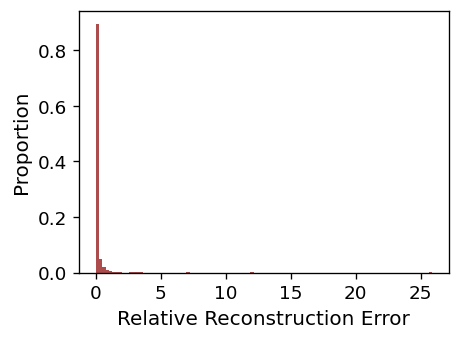

In [20]:
# Get single sample prediction
model.eval()
with torch.no_grad():
    x_input = X_val[sample_idx:sample_idx+1].to(device)
    _, _, _, x_hat = model(x_input)
    x_hat_np = x_hat.cpu().numpy()[0]

x_true = X_val[sample_idx].cpu().numpy()

# Relative error for signal
signal_errors = np.abs(x_hat_np[6:] - x_true[6:]) / (np.abs(x_true[6:]) + 1e-8)

# Plot
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(signal_errors, bins=100, color="darkred", alpha=0.7, edgecolor="none",
        weights=np.ones_like(signal_errors) / len(signal_errors))
ax.set_xlabel("Relative Reconstruction Error")
ax.set_ylabel("Proportion")

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()

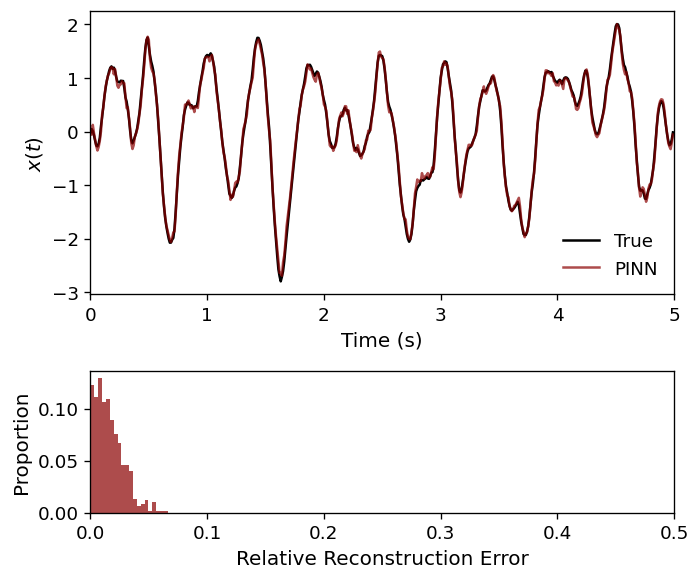

In [45]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), gridspec_kw={'height_ratios': [2, 1]})

# Top: signal overlay
ax1.plot(t[:500], x_true[:500], lw=1.5, color="black", label="True")
ax1.plot(t[:500], x_hat_np[:500], lw=1.5, color="darkred", alpha=0.7, label="PINN")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("$x(t)$")
ax1.legend(frameon=False)
ax1.set_xlim([0, 5])

# Bottom: error histogram
signal_range = np.max(np.abs(x_true[6:])) 
signal_errors = np.abs(x_hat_np[6:] - x_true[6:]) / signal_range

ax2.hist(signal_errors, bins=20, color="darkred", alpha=0.7, edgecolor="none",
         weights=np.ones_like(signal_errors) / len(signal_errors))
ax2.set_xlabel("Relative Reconstruction Error")
ax2.set_ylabel("Proportion")
ax2.set_xlim([0, 0.5])  # trim long tail

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(True)

plt.tight_layout()
plt.show()

In [22]:
def plot_coefficients_by_p(model, X, coeffs_true, p_true, device, p_max=6, p_min=2, title=""):
    model.eval()
    
    n_classes = p_max - p_min + 1  # 5 classes for p=2,3,4,5,6
    fig, axes = plt.subplots(1, n_classes, figsize=(4 * n_classes, 4))
    
    with torch.no_grad():
        for p_idx in range(n_classes):
            ax = axes[p_idx]
            p_actual = p_idx + p_min  # True AR order: 2,3,4,5,6
            
            mask = (p_true == p_idx).numpy() if torch.is_tensor(p_true) else (p_true == p_idx)
            if not mask.any():
                ax.set_title(f'p={p_actual} (no example)')
                continue
            
            idx = np.where(mask)[0][0]
            
            if torch.is_tensor(X):
                x = X[idx:idx+1].clone().detach().to(device)
            else:
                x = torch.from_numpy(X[idx:idx+1]).float().to(device)
            
            coeffs_pred, _, p_hard, _ = model(x)
            coeffs_pred = coeffs_pred.cpu().numpy()[0]  # (600, max_ar_order)
            p_pred = p_hard.item() + p_min  # Predicted AR order
            
            # Plot true coefficients (p_actual of them)
            for k in range(p_actual):
                label = 'True' if k == 0 else None
                ax.plot(coeffs_true[idx, :, k], 'k-', alpha=0.7, label=label)
            
            # Plot predicted coefficients (p_pred of them)
            for k in range(p_pred):
                label = 'Pred' if k == 0 else None
                ax.plot(coeffs_pred[:, k], color='darkred', alpha=0.7, label=label)
            
            ax.set_title(f'True p={p_actual}, Pred p={p_pred}')
            ax.set_xlabel('Time')
            ax.set_ylabel('Coefficient')
            ax.legend()
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

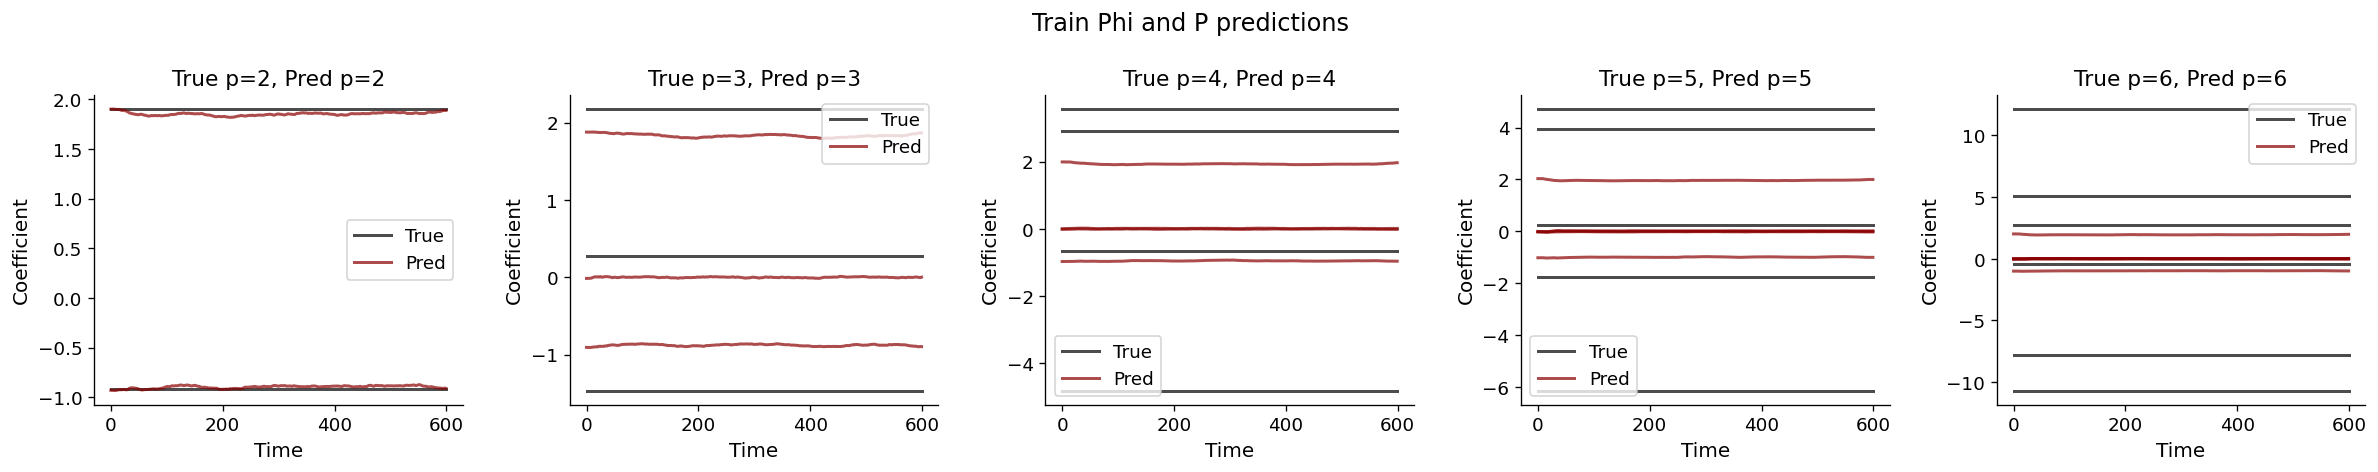

In [23]:
plot_coefficients_by_p(model, X_train, coef_train, p_train, device, title="Train Phi and P predictions")

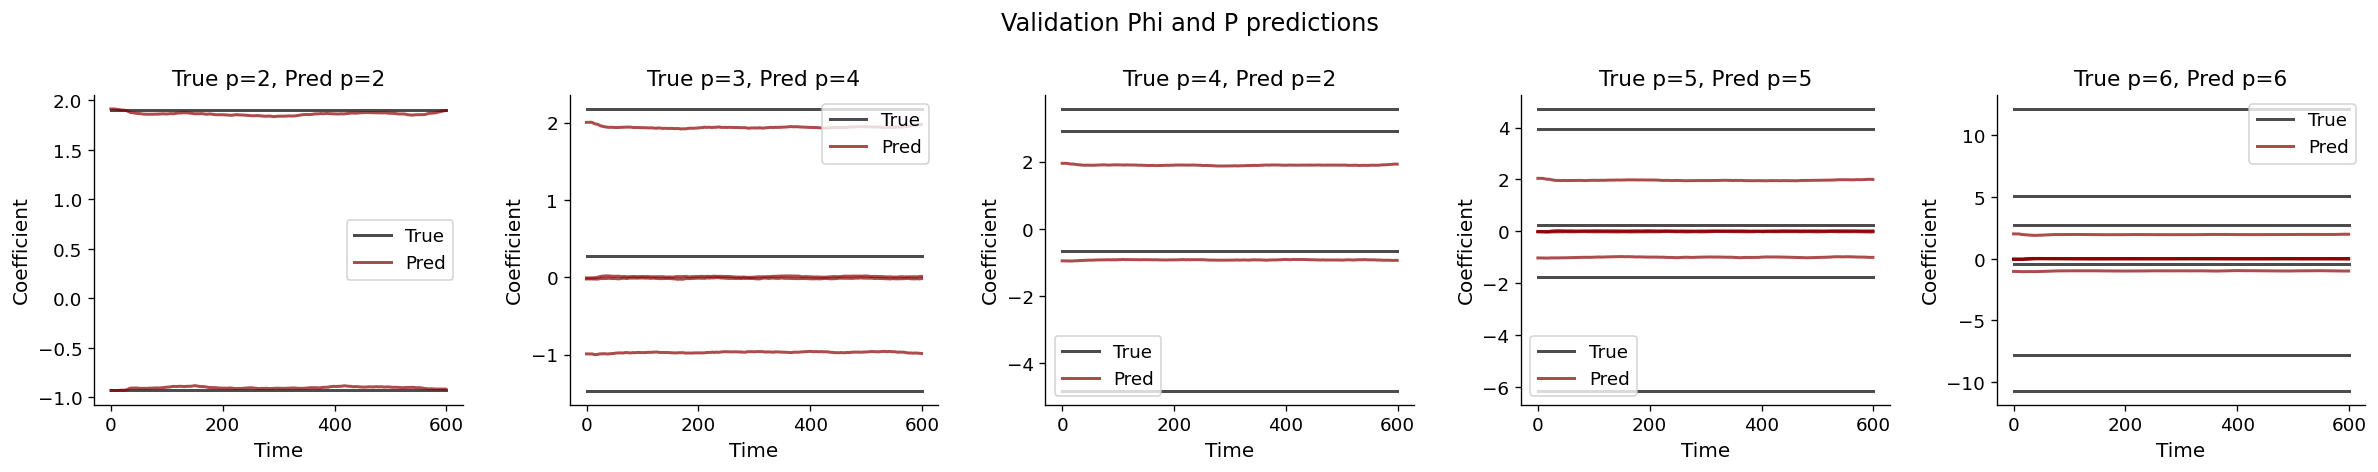

In [24]:
plot_coefficients_by_p(model, X_val, coef_val, p_val, device, title="Validation Phi and P predictions")

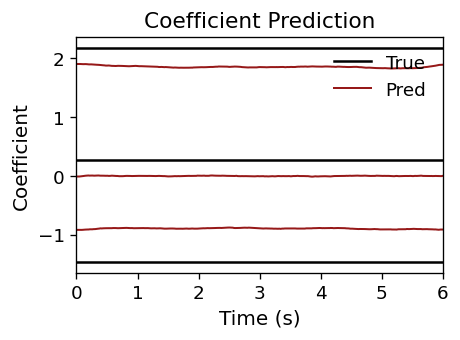

In [25]:
# Find a p=3 sample from training set (class index 1 since p_min=2)
p3_mask = (p_train == 1).numpy() if torch.is_tensor(p_train) else (p_train == 1)
p3_idx = np.where(p3_mask)[0][100]
p_actual = 3  # AR order

# Get the signal and true coefficients
signal_p3 = X_train[p3_idx].numpy() if torch.is_tensor(X_train) else X_train[p3_idx]
coeffs_true_p3 = coef_train[p3_idx]  # (T, p_max)

# Get model predictions
model.eval()
with torch.no_grad():
    x_input = X_train[p3_idx:p3_idx+1].to(device)
    coeffs_pred, _, p_hard, _ = model(x_input)
    coeffs_pred_p3 = coeffs_pred.cpu().numpy()[0]  # (T, max_ar_order)
    p_pred = p_hard.item() + 2  # predicted AR order

# Plot coefficients like the reference image
fig, ax = plt.subplots(figsize=(4, 3))
T = len(signal_p3)
t = np.arange(T)

# Plot true coefficients as horizontal lines (they're constant)
for k in range(p_actual):
    true_val = coeffs_true_p3[0, k]  # constant value
    label = 'True' if k == 0 else None
    ax.axhline(true_val, color='black', lw=1.5, label=label)

# Plot predicted coefficients as time-varying lines
for k in range(p_pred):
    label = 'Pred' if k == 0 else None
    ax.plot(t / 100 , coeffs_pred_p3[:, k], color='darkred', lw=1.2, alpha=0.9, label=label)

ax.set_title(f"Coefficient Prediction")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Coefficient")
ax.legend(frameon=False, loc="upper right")

# Full box (all spines visible)
for spine in ax.spines.values():
    spine.set_visible(True)

# Set x-ticks at each second (assuming Fs=100 Hz)
sec_ticks = np.arange(0, T/100 + 1, 1)
ax.set_xticks(sec_ticks)
ax.set_xlim([0, T/100])

plt.tight_layout()
plt.show()

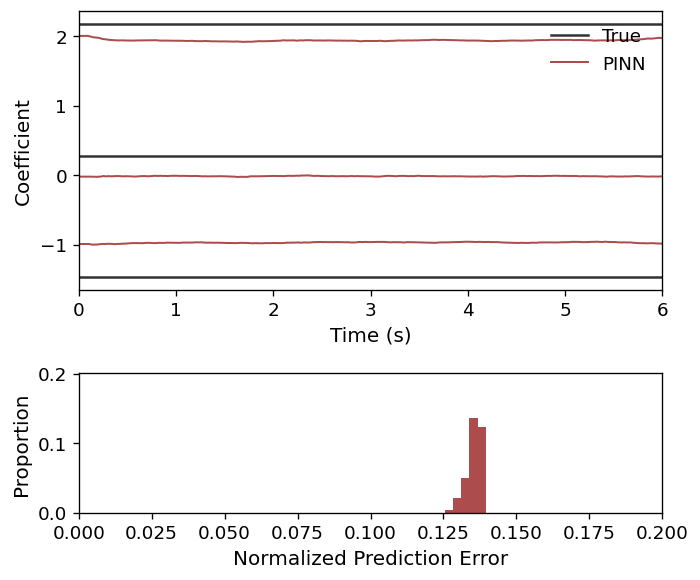

In [41]:
# Pick a sample
p3_mask = (p_val == 1).numpy() if torch.is_tensor(p_val) else (p_val == 1)
sample_idx = np.where(p3_mask)[0][0]

# Get true coefficients
coeffs_true_sample = coef_val[sample_idx]  # (T, p_max)

# Get predicted coefficients
model.eval()
with torch.no_grad():
    x_input = X_val[sample_idx:sample_idx+1].to(device)
    coeffs_pred, _, p_hard, _ = model(x_input)
    coeffs_pred_sample = coeffs_pred.cpu().numpy()[0]  # (T, max_ar_order)
    p_pred = p_hard.item() + 2

p_actual = 3
T = coeffs_true_sample.shape[0]
t = np.arange(T) / 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), height_ratios=[2, 1])

# Top: coefficient overlay
for k in range(p_actual):
    label_true = "True" if k == 0 else None
    label_pred = "PINN" if k == 0 else None
    ax1.plot(t, coeffs_true_sample[:, k], color="black", lw=1.5, alpha=0.8, label=label_true)
    ax1.plot(t, coeffs_pred_sample[:, k], color="darkred", lw=1.2, alpha=0.7, label=label_pred)

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Coefficient")
ax1.legend(frameon=False)
ax1.set_xlim([0, T / 100])

# Bottom: absolute coefficient error histogram
# Total range across all coefficients
coeff_range = np.max(coeffs_true_sample[:, :p_actual]) - np.min(coeffs_true_sample[:, :p_actual])

# Signed error normalized by range, for all 3 coefficients
errors = ((coeffs_pred_sample[:, :p_actual] - coeffs_true_sample[:, :p_actual]) / coeff_range).flatten()

ax2.hist(errors, bins=80, color="darkred", alpha=0.7, edgecolor="none",
         weights=np.ones_like(errors) / len(errors))
ax2.axvline(0, color="black", lw=1, linestyle="--")
ax2.set_xlabel("Normalized Prediction Error")
ax2.set_ylabel("Proportion")
ax2.set_xlim([0, 0.2])

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(True)

plt.tight_layout()
plt.show()

In [28]:
import sys
sys.path.insert(0, '/home/rudra/Documents/NeuralFieldManifold')

In [29]:
from NeuralFieldManifold.models import AR
from NeuralFieldManifold.embedders import embed
from scipy import signal
from scipy.signal import hilbert, butter, filtfilt, spectrogram


In [ ]:
def bandpass_filter(x, Fs, low, high, order=4):
    wn = [low/(Fs/2), high/(Fs/2)]
    sos = signal.butter(order, wn, btype='bandpass', output='sos')
    return signal.sosfiltfilt(sos, x)

def envelope_normalize(x, fs, fband=(15, 30), env_lp_hz=5.0, eps=1e-6):
    b, a = signal.butter(4, np.array(fband)/(fs/2), btype='bandpass')
    x_bp = signal.filtfilt(b, a, x)
    z = hilbert(x_bp)
    A = np.abs(z)
    if env_lp_hz is not None:
        b_lp, a_lp = signal.butter(2, env_lp_hz/(fs/2), btype='low')
        A = signal.filtfilt(b_lp, a_lp, A)
    x_flat = x_bp / (A + eps)
    x_flat *= np.median(A)
    return x_flat, x_bp, A

def process_synthetic_signal(x, Fs, target_Fs=None, apply_bandpass=False, 
                            bandpass_low=1, bandpass_high=20):
    """Process synthetic TVAR signal (minimal preprocessing for clean simulated data).
    
    Args:
        x: 1D array, signal from generate_tvar_sample
        Fs: Sampling frequency
        target_Fs: Target sampling frequency for downsampling (None = no downsampling)
        apply_bandpass: Whether to apply bandpass filter
        bandpass_low, bandpass_high: Bandpass filter cutoffs
    
    Returns:
        xs: Processed signal
        xs_raw: Raw/filtered signal before normalization
        Fs_out: Output sampling frequency
    """
    x = np.asarray(x).ravel()
    
    # Optional bandpass filtering (usually not needed for synthetic data)
    if apply_bandpass:
        xs_raw = bandpass_filter(x, Fs, low=bandpass_low, high=bandpass_high)
    else:
        xs_raw = x.copy()
    
    # Downsample if requested
    if target_Fs is not None and Fs > target_Fs:
        r = int(np.floor(Fs / target_Fs))
        xs_raw = signal.decimate(xs_raw, r, ftype='iir', zero_phase=True).astype(float)
        Fs_out = Fs / r
    else:
        Fs_out = Fs
    
    # For synthetic data, just use as-is (already clean from generate_tvar_sample)
    xs = xs_raw
    
    return xs, xs_raw, Fs_out

def process_signal(LFP, chan, Fs, time_window, 
                   notch_freq=50, notch_Q=30,
                   bandpass_low=4, bandpass_high=30,
                   fband=(4, 30), env_lp_hz=None,
                   target_Fs=500):
    """Process LFP signal with notch filter, bandpass, envelope normalization, and downsampling."""
    filtered = signal.filtfilt(*signal.iirnotch(notch_freq, notch_Q, Fs), LFP[time_window, chan])
    x = np.asarray(filtered).ravel()
    xs_raw = bandpass_filter(x, Fs, low=bandpass_low, high=bandpass_high)
    
    # Downsample if needed (before envelope normalization for efficiency)
    if Fs > target_Fs:
        r = int(np.floor(Fs / target_Fs))
        xs_raw = signal.decimate(xs_raw, r, ftype='iir', zero_phase=True).astype(float)
        Fs_out = Fs / r
    else:
        Fs_out = Fs
    
    xs, _, _ = envelope_normalize(xs_raw, Fs_out, fband=fband, env_lp_hz=env_lp_hz)
    return xs, xs_raw, Fs_out


def fit_ar_model(xs, Fs, p=4, train_frac=0.9, refresh_every=10):
    X, y = AR.lag_matrix(xs, p)
    ntr = int(train_frac * len(y))
    X_tr, y_tr = X[:ntr], y[:ntr]
    w = AR.fit(X_tr, y_tr)
    N_te = len(y) - ntr
    t0 = p + ntr
    true_test = xs[t0 : t0 + N_te]
    yhat_ctrl = AR.hybrid_predict(xs, w, p, start_idx=t0, n_steps=N_te, refresh_every=refresh_every)
    full_pred = AR.hybrid_predict(xs, w, p, start_idx=p, n_steps=len(xs)-p, refresh_every=refresh_every)
    xs_pred_full = np.concatenate([xs[:p], full_pred])
    mse, mae, corr = AR.metrics(true_test, yhat_ctrl)
    return {
        'w': w, 'p': p, 'ntr': ntr, 'y': y, 'true_test': true_test,
        'yhat_ctrl': yhat_ctrl, 'xs_pred_full': xs_pred_full, 't0': t0,
        'mse': mse, 'mae': mae, 'corr': corr, 'refresh_every': refresh_every
    }

In [46]:
p3_indices = np.where(p_val.numpy() == 1)[0]
print(f"Found {len(p3_indices)} AR(3) samples in validation set")

sample_idx = p3_indices[0]

xs = X_val.cpu().numpy()[sample_idx]

# Use PINN prediction instead of OLS
model.eval()
with torch.no_grad():
    x_input = X_val[sample_idx:sample_idx+1].to(device)
    coeffs_pred, _, p_hard, x_hat = model(x_input)
    p_pred = p_hard.item() + 2  # predicted AR order
    x_hat_np = x_hat.cpu().numpy()[0]  # (600,) full PINN prediction

# Use full signal for embedding (skip first p_max samples where x_hat is zero)
p_max = 6
true_full = xs[p_max:]
pinn_pred_full = x_hat_np[p_max:]

# Metrics
mse = np.mean((true_full - pinn_pred_full) ** 2)
mae = np.mean(np.abs(true_full - pinn_pred_full))
corr = np.corrcoef(true_full, pinn_pred_full)[0, 1]

print(f"PINN (pred p={p_pred}): MSE={mse:.6f}, MAE={mae:.6f}, corr={corr:.3f}")

Found 199 AR(3) samples in validation set
PINN (pred p=4): MSE=0.003258, MAE=0.045942, corr=0.999


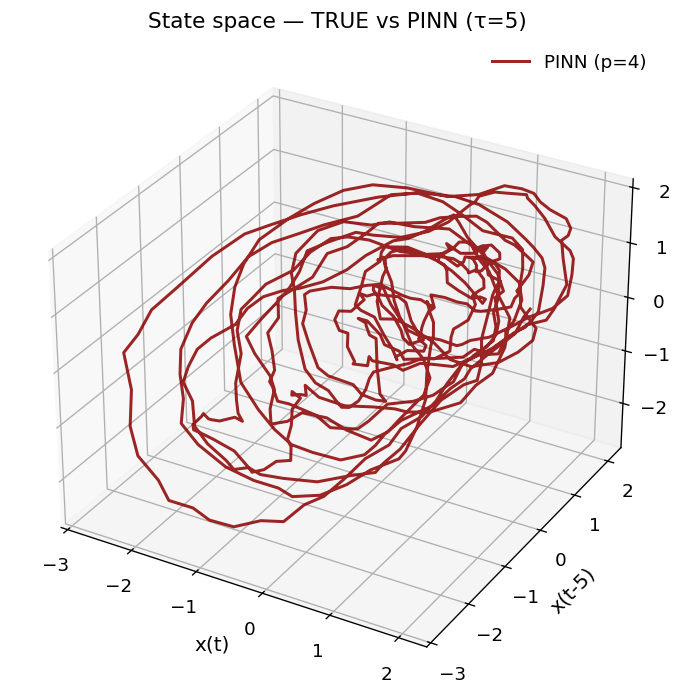

In [51]:
def plot_state_space(X3_true, X3_pred, p, tau, method_label="PINN", color_true="black", color_pred="darkred"):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    # ax.plot(X3_true[:,0], X3_true[:,1], X3_true[:,2], label="TRUE", color=color_true, alpha=0.85)
    ax.plot(X3_pred[:,0], X3_pred[:,1], X3_pred[:,2], label=f"{method_label} (p={p})", color=color_pred, alpha=0.85)
    ax.set_title(f"State space — TRUE vs {method_label} (τ={tau})")
    ax.set_xlabel("x(t)")
    ax.set_ylabel(f"x(t-{tau})")
    ax.set_zlabel(f"x(t-{2*tau})")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

tau = 5

# Normalize PINN prediction to match true signal statistics
pinn_norm = pinn_pred_full - np.mean(pinn_pred_full)
pinn_norm = pinn_norm * (np.std(true_full) / (np.std(pinn_norm) + 1e-12)) + np.mean(true_full)

X3_true = embed(true_full, 3, tau)
X3_pinn = embed(pinn_norm, 3, tau)

plot_state_space(X3_true, X3_pinn, p_pred, tau, method_label="PINN")

OLS AR(3): MSE=0.222435, MAE=0.332898, corr=0.885


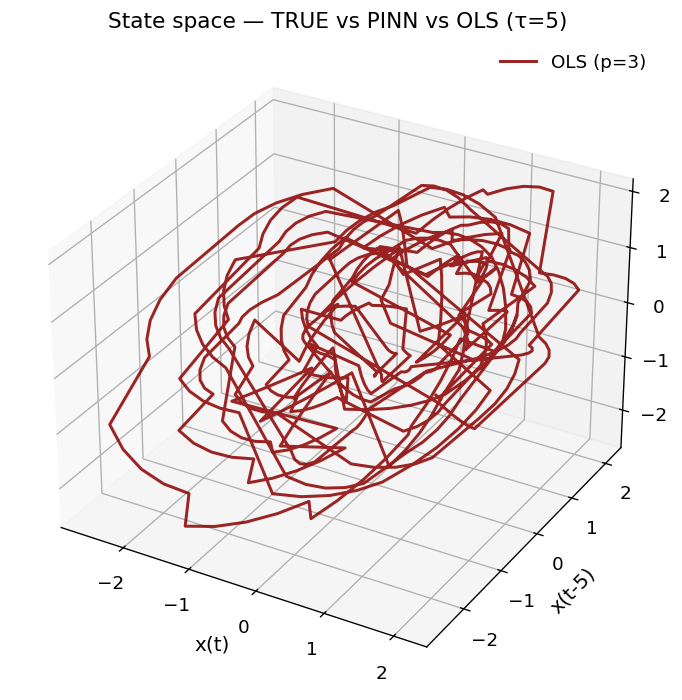

In [49]:
def plot_state_space_compare(X3_true, X3_pinn, X3_ols, p_pinn, p_ols, tau,
                             color_true="black", color_pinn="darkred", color_ols="steelblue"):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    # ax.plot(X3_true[:,0], X3_true[:,1], X3_true[:,2], label="TRUE", color=color_true, alpha=0.85)
    # ax.plot(X3_pinn[:,0], X3_pinn[:,1], X3_pinn[:,2], label=f"PINN (p={p_pinn})", color=color_pinn, alpha=0.85)
    ax.plot(X3_ols[:,0], X3_ols[:,1], X3_ols[:,2], label=f"OLS (p={p_ols})", color=color_pinn, alpha=0.85)
    ax.set_title(f"State space — TRUE vs PINN vs OLS (τ={tau})")
    ax.set_xlabel("x(t)")
    ax.set_ylabel(f"x(t-{tau})")
    ax.set_zlabel(f"x(t-{2*tau})")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# --- OLS AR fit on the same validation sample ---
p_ols = 3  # match the true order
Xlag, ylag = AR.lag_matrix(xs, p_ols)
w_ols = AR.fit(Xlag, ylag)
# Full hybrid prediction (refresh_every=10 for fair comparison)
ols_pred_full = AR.hybrid_predict(xs, w_ols, p_ols, start_idx=p_max, n_steps=len(xs)-p_max, refresh_every=10)

ols_mse, ols_mae, ols_corr = AR.metrics(true_full, ols_pred_full)
print(f"OLS AR({p_ols}): MSE={ols_mse:.6f}, MAE={ols_mae:.6f}, corr={ols_corr:.3f}")

tau = 5

# Normalize PINN prediction
pinn_norm = pinn_pred_full - np.mean(pinn_pred_full)
pinn_norm = pinn_norm * (np.std(true_full) / (np.std(pinn_norm) + 1e-12)) + np.mean(true_full)

# Normalize OLS prediction
ols_norm = ols_pred_full - np.mean(ols_pred_full)
ols_norm = ols_norm * (np.std(true_full) / (np.std(ols_norm) + 1e-12)) + np.mean(true_full)

X3_true = embed(true_full, 3, tau)
X3_pinn = embed(pinn_norm, 3, tau)
X3_ols = embed(ols_norm, 3, tau)

plot_state_space_compare(X3_true, X3_pinn, X3_ols, p_pred, p_ols, tau)

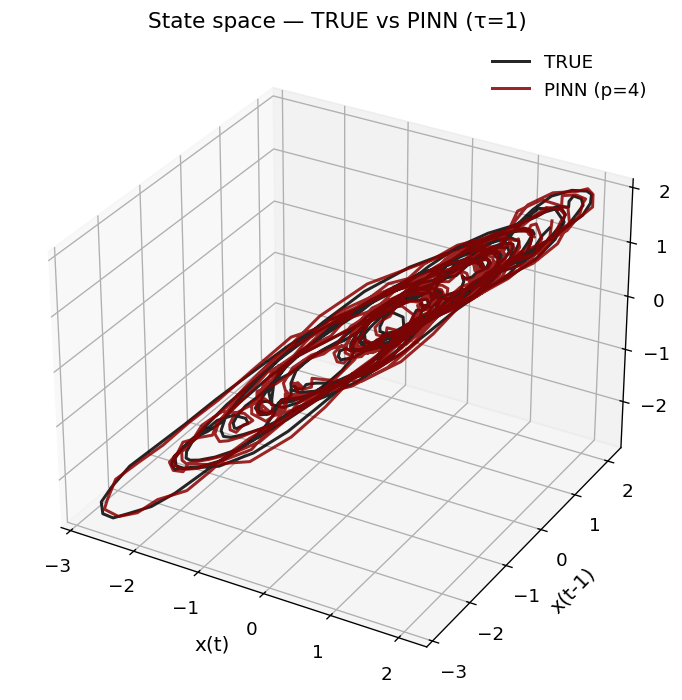

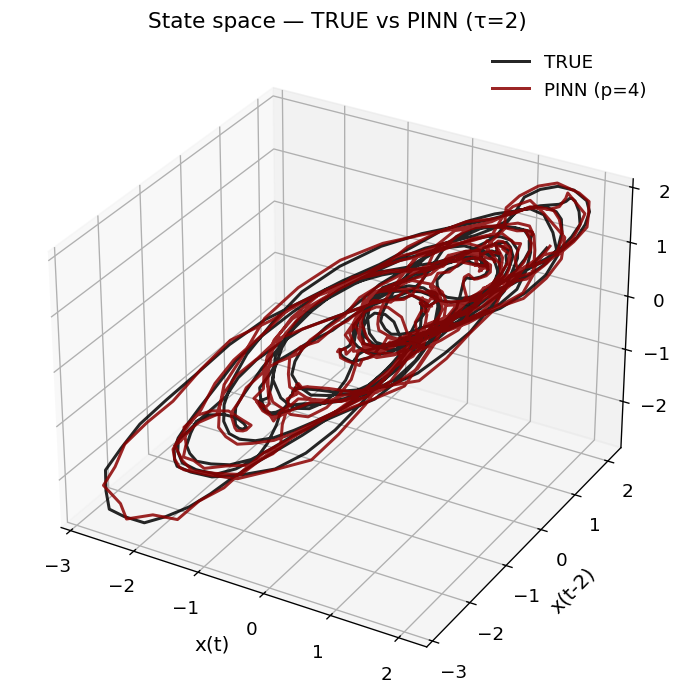

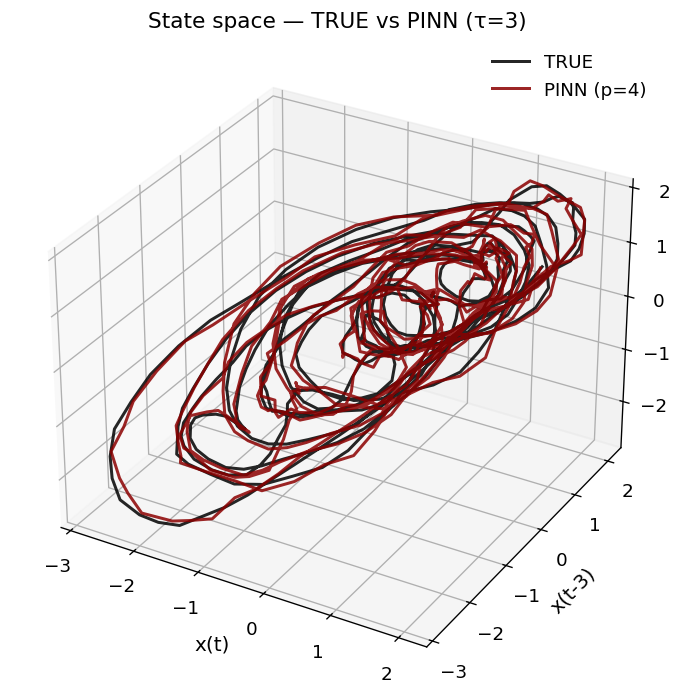

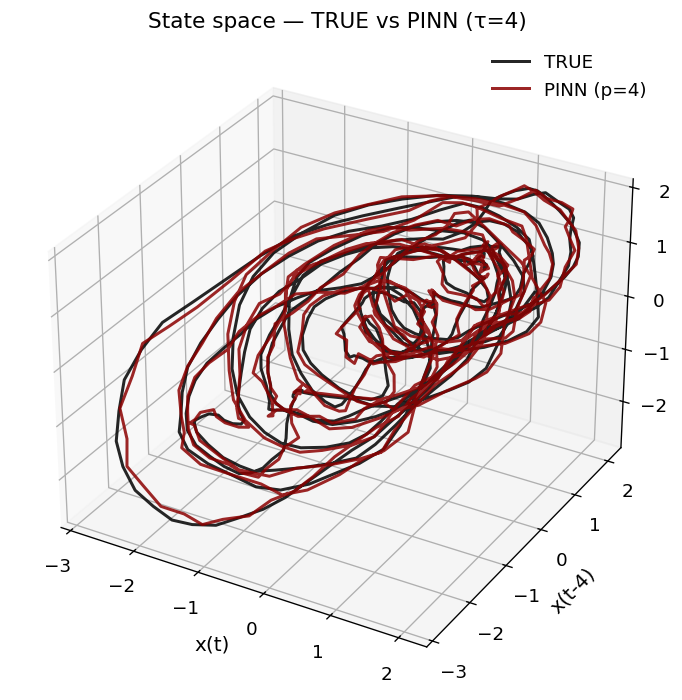

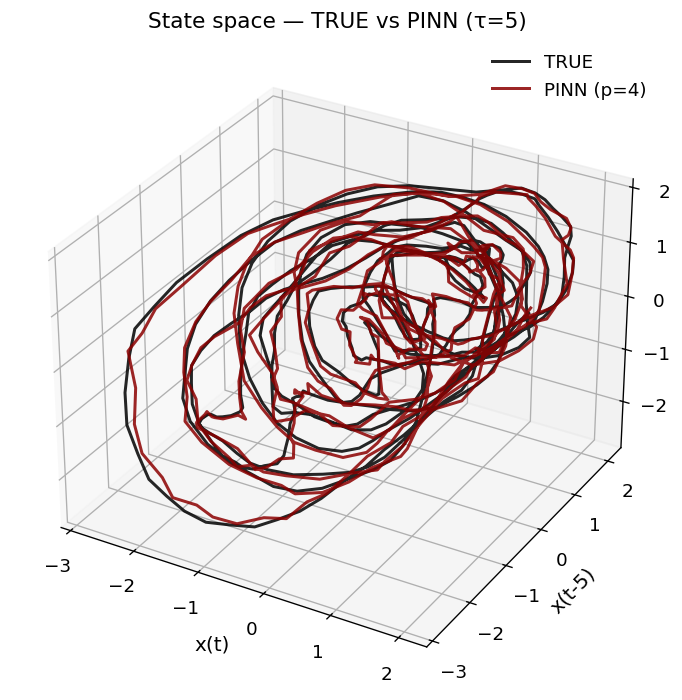

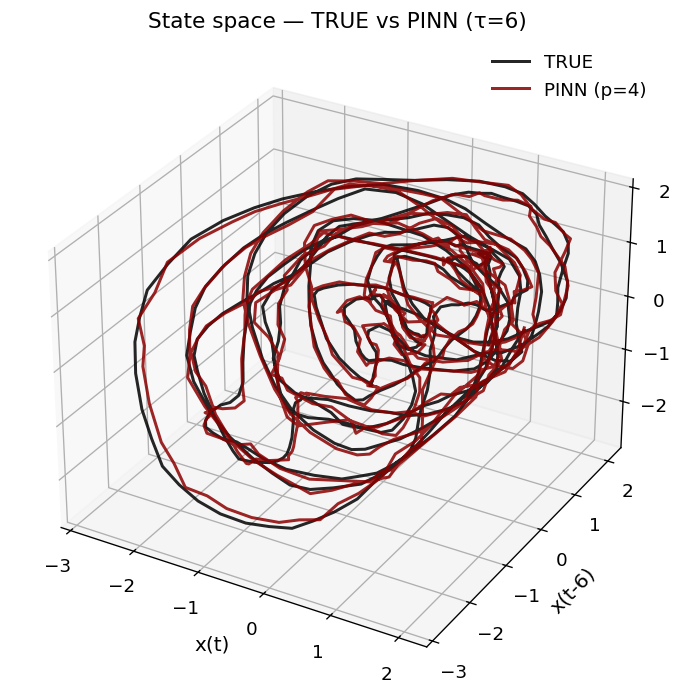

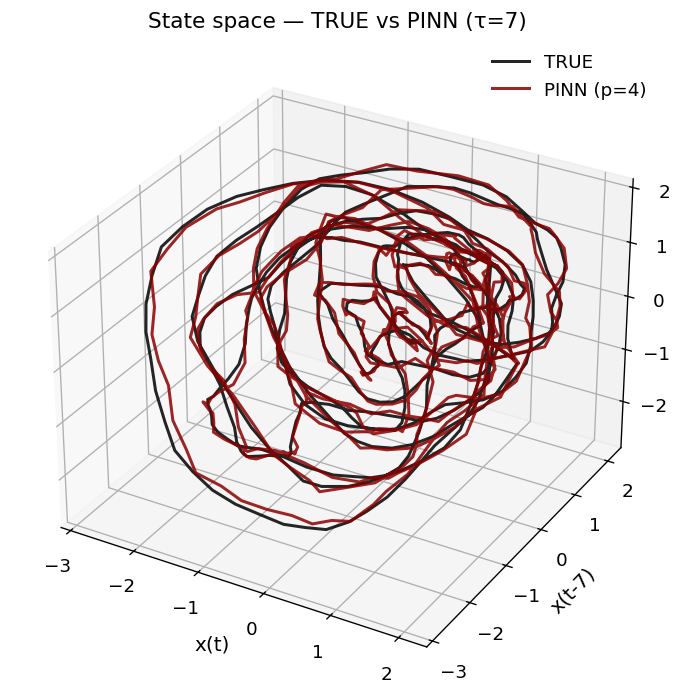

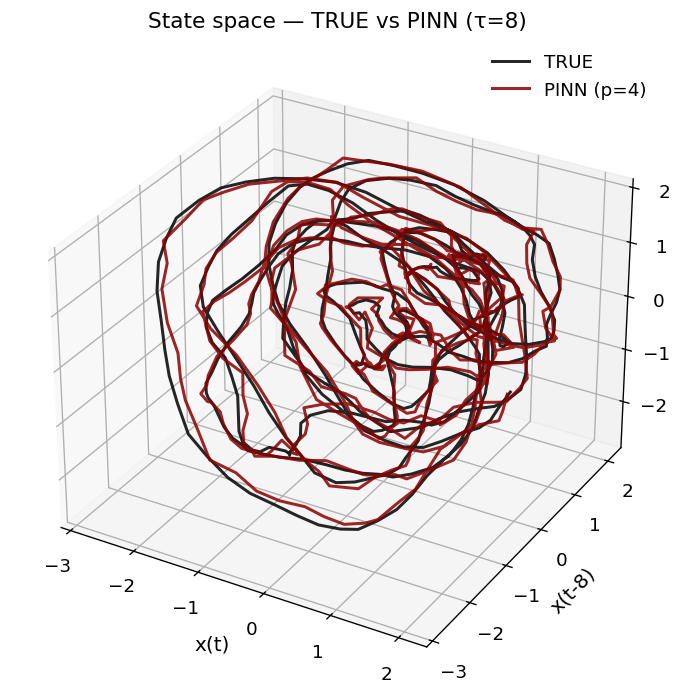

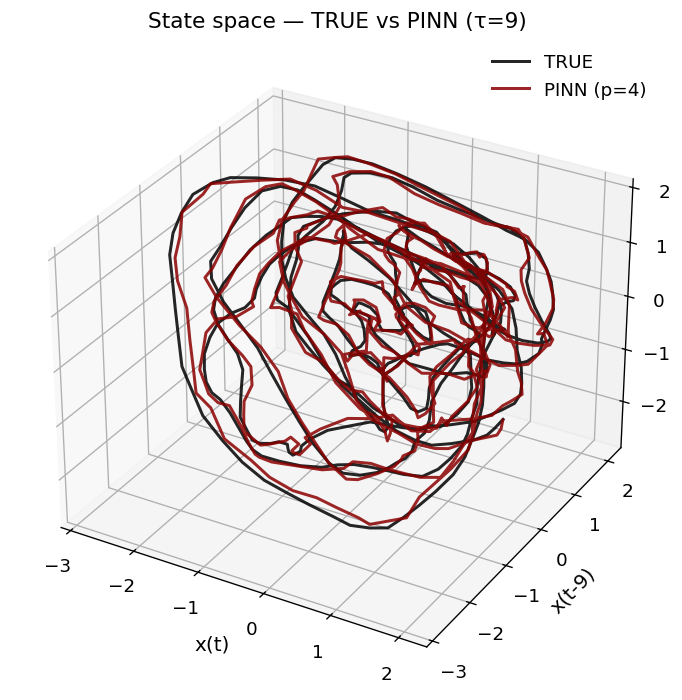

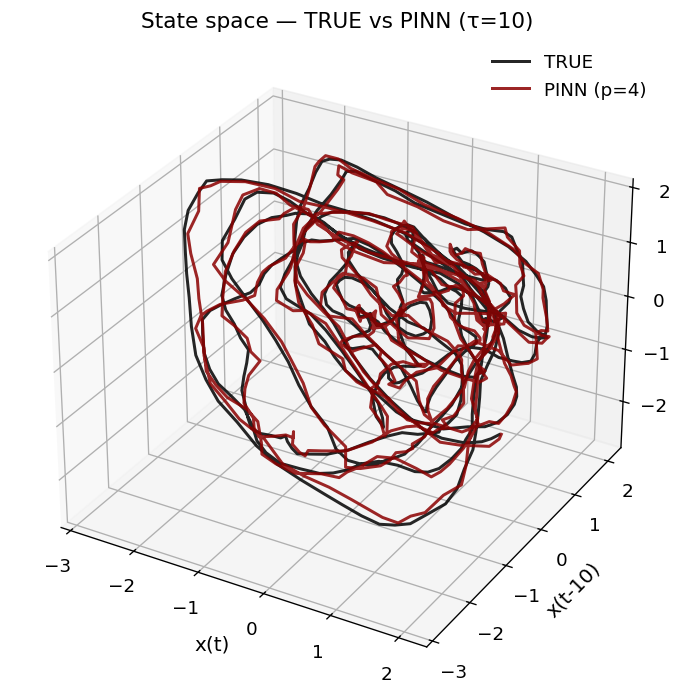

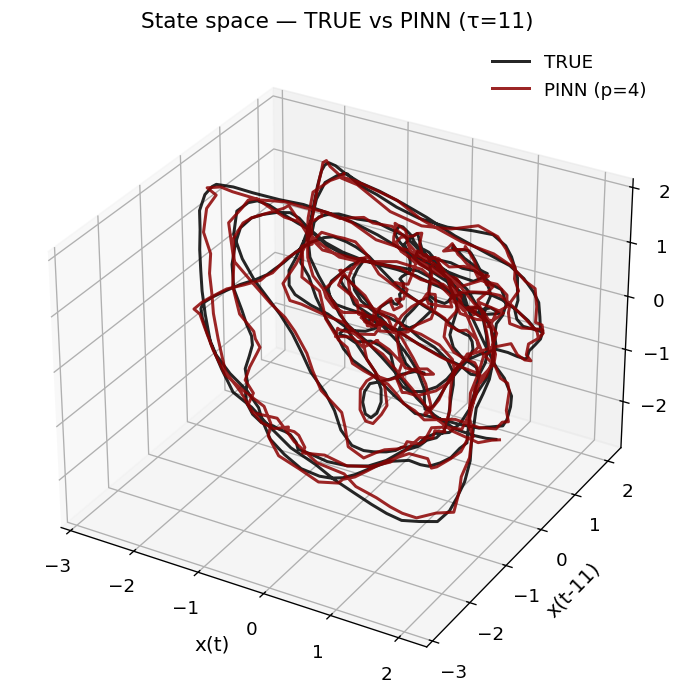

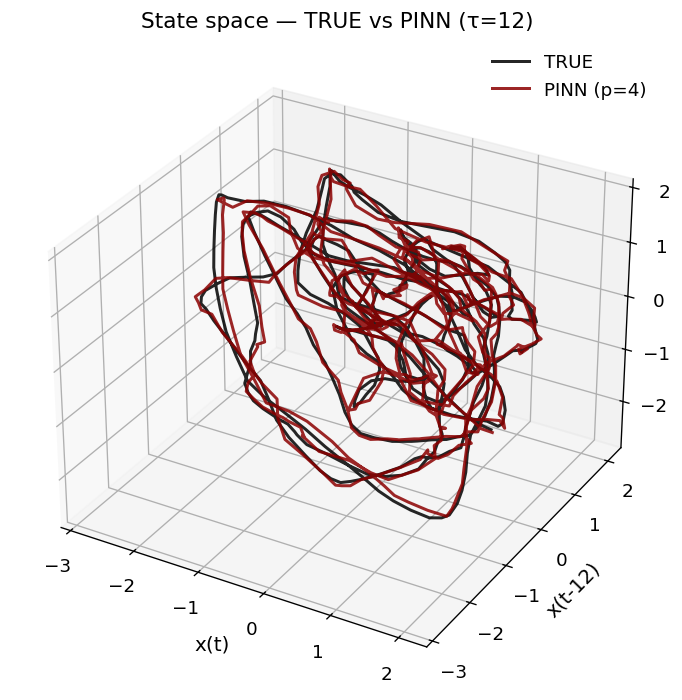

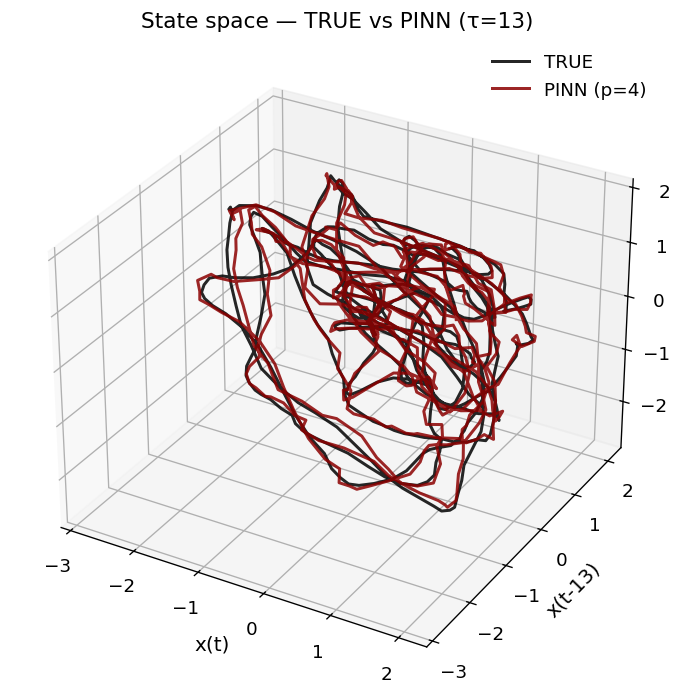

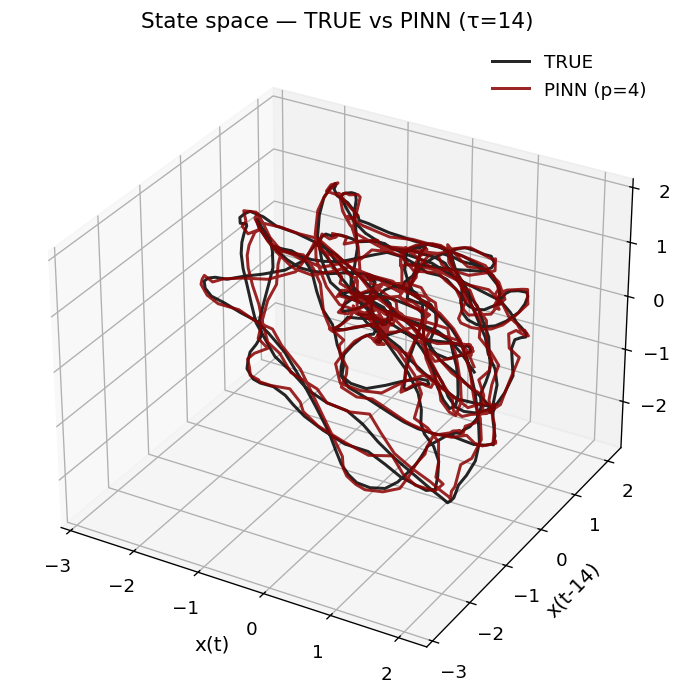

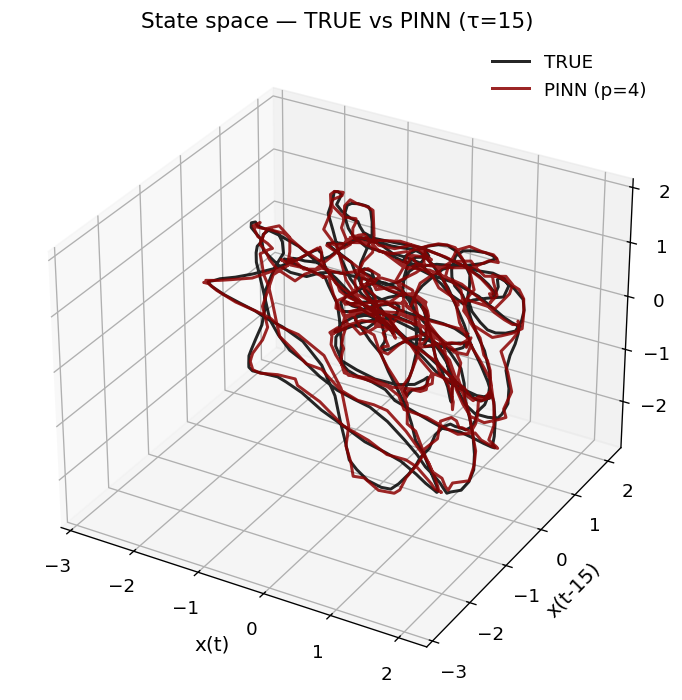

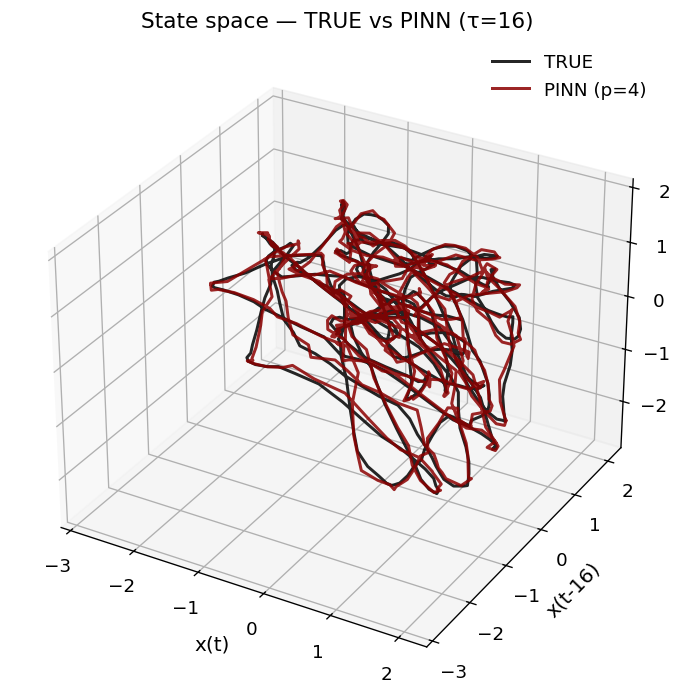

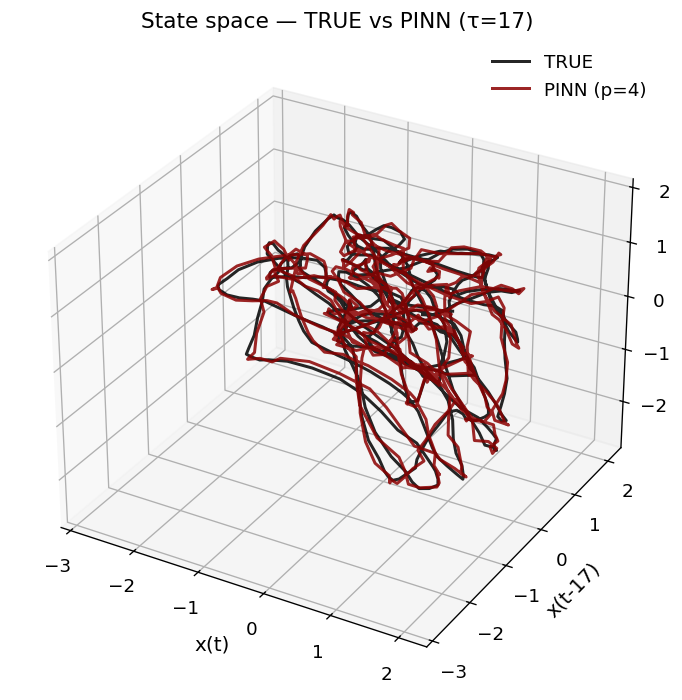

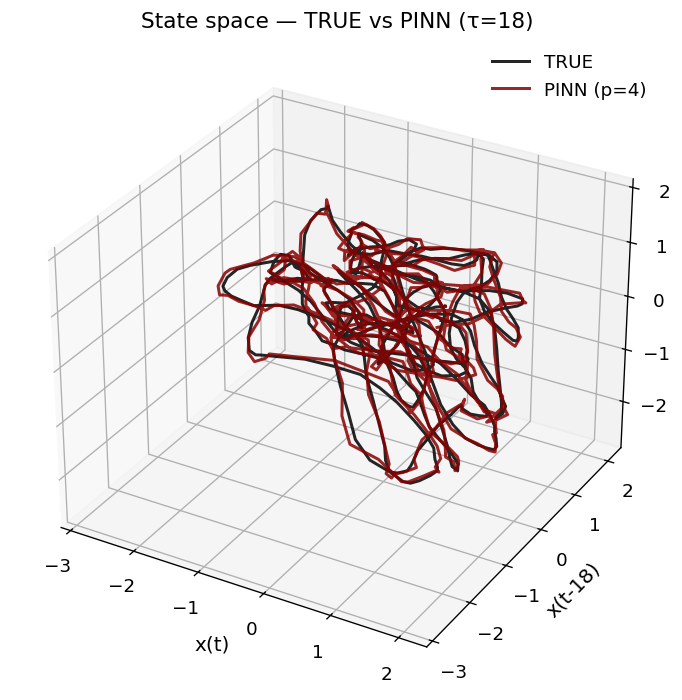

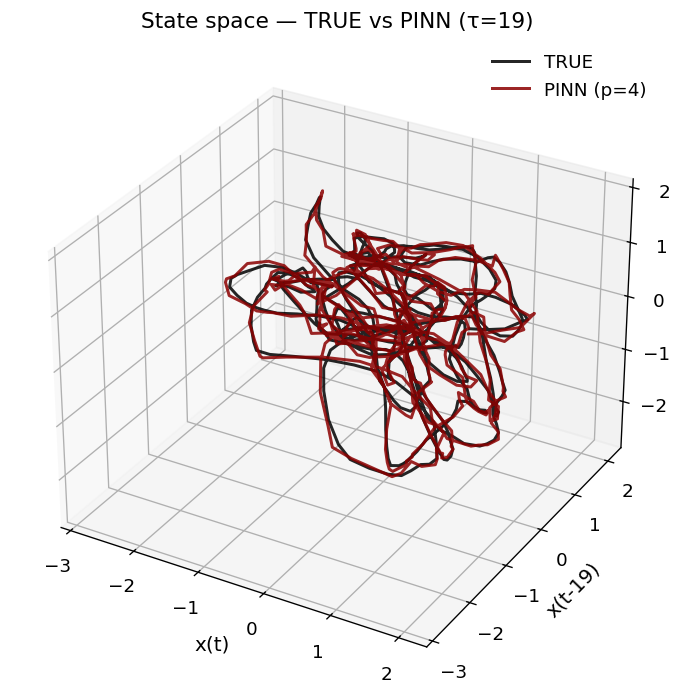

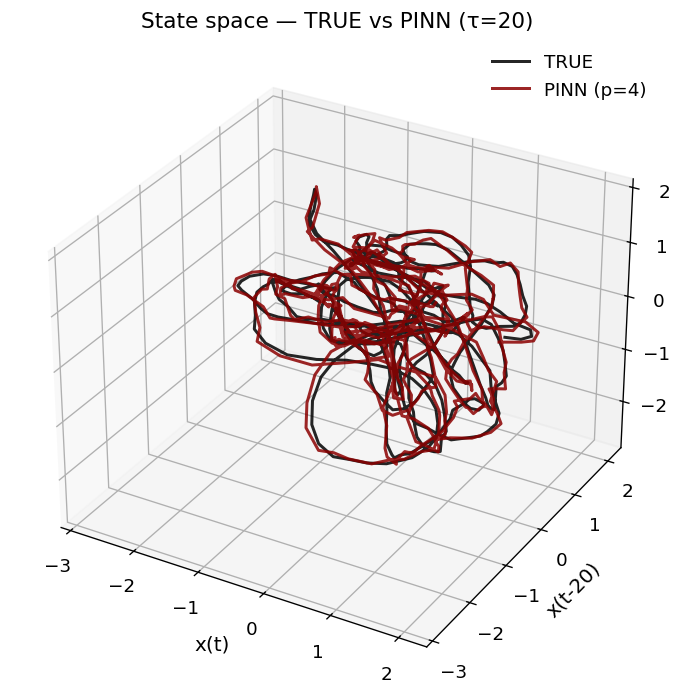

In [50]:
for tau in range(1, 21, 1):
    pinn_norm = pinn_pred_full - np.mean(pinn_pred_full)
    pinn_norm = pinn_norm * (np.std(true_full) / (np.std(pinn_norm) + 1e-12)) + np.mean(true_full)

    X3_true = embed(true_full, 3, tau)
    X3_pinn = embed(pinn_norm, 3, tau)

    plot_state_space(X3_true, X3_pinn, p_pred, tau, method_label="PINN")